<a href="https://colab.research.google.com/github/VICO-27/CSEC-ASTU-Data-Science-Bootcamp/blob/main/Daily%20Task%201/Daily%20Task%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Pandas Hands-On Project — Daily Task 1  
### Superstore Dataset  

#### Objective  
In this task, I begin by examining the Superstore dataset to understand its structure, the type of information it contains, and any potential data quality issues. This initial exploration is important because every further analysis depends on how well the data is understood at this stage.

**Author:** Ashenafi Deresa

##1. Import Libraries

In [37]:
import pandas as pd
import numpy as np

Pandas is used to load and analyze the dataset, while NumPy supports numerical operations when needed.

##2. Load Dataset


In [38]:
import pandas as pd

# Added encoding because this specific file often has special characters
try:
    df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')
    print("Success! Dataset loaded.")
except FileNotFoundError:
    print("Error: Make sure you uploaded 'Sample - Superstore.csv' to the Colab file sidebar!")

Success! Dataset loaded.


The dataset is loaded into a DataFrame, which allows structured exploration and manipulation of the data.

##3. Preview the Data

In [39]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


This provides a quick preview of the dataset, showing columns such as Order Date, Sales, Profit, Category, and Region.  
From this, it is clear that the dataset contains transactional sales data.

##4. Check Dataset Structure

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

The dataset contains 9,994 rows and multiple columns with a mix of data types.

- Numerical columns: Sales, Profit, Quantity, Discount  
- Categorical columns: Category, Region, Segment, City  
- Date columns: Order Date and Ship Date (currently stored as object)

There are missing values in some columns, which will need to be handled during the data cleaning step.

##5. Dataset Shape

In [41]:
df.shape

(9994, 21)

The dataset has 9,994 rows, indicating a fairly large transactional dataset suitable for meaningful analysis.

##6. Column Names

In [42]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

The dataset includes customer details, product information, and sales metrics, which suggests it can be analyzed from multiple perspectives such as customer behavior, product performance, and regional trends.

##7. Summary Statistics (Numerical)

In [43]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


Sales and Profit show a wide range of values, indicating variability in transactions.

- Profit includes negative values → some transactions are loss-making  
- Sales vary significantly → presence of both small and large orders  

This suggests the need to investigate profitability patterns later.

##8. Summary Statistics (Categorical)

In [44]:
df.describe(include='object')

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,1237,1334,4,793,793,3,1,531,49,4,1862,3,17,1850
top,CA-2017-100111,9/5/2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,35,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,48


Categorical features such as Category, Region, and Segment have a limited number of unique values, making them useful for grouping and aggregation.

Some columns like Product Name and City have many unique values, which may make direct analysis more complex.

##9. Unique Values

In [45]:
df.nunique()

,0
Row ID,9994
Order ID,5009
Order Date,1237
Ship Date,1334
Ship Mode,4
Customer ID,793
Customer Name,793
Segment,3
Country,1
City,531


The dataset reveals important structural characteristics:

- Row ID is unique for each row → acts as an index  
- Order ID has fewer unique values than rows → each order contains multiple items  
- Customer ID and Customer Name match in uniqueness → data is consistent  
- Country has only one value → not useful for analysis  
- Category (3), Region (4), Segment (3) → key grouping features  
- City (531) and Product Name (1850) → high-cardinality features  
- Sales and Profit have many unique values → continuous variables  

This confirms that the dataset is at the **transaction level**, where each row represents a product within an order, not a full order itself.

### Initial Observation  

The dataset represents retail transaction data with a mix of customer, product, and sales information.  
It includes both categorical features for grouping and numerical features for measuring performance.  
Some columns may require cleaning (such as date formats and missing values), but overall the dataset is well-structured and suitable for deeper analysis.

##Task 2: Data Cleaning

##2.1: Identify and Handle Missing Values

In [46]:
# Checking for missing values across all columns
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


##Insight: Data Integrity & Reliability
The dataset shows 100% completeness across all 9,994 records. This zero-null status eliminates "imputation bias" and ensures that upcoming financial metrics (Sales/Profit) are derived from a pure population, removing the need for data removal or synthetic filling that could distort the analysis.

#2.2: Convert Data Types

In [47]:
# Converting Order Date and Ship Date to datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Confirming the change
df[['Order Date', 'Ship Date']].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


##Insight: Temporal Standardization
Converting string dates into datetime64 objects transforms static text into "time-aware" dimensions. This structural change is critical for calculating shipping lead times and ensuring chronological sorting; without it, monthly trend analysis would fail due to alphabetical sorting errors (e.g., April appearing before January).

##Task 3.1: Temporal Feature Engineering

In [48]:
# Extracting Year and Month from the Order Date column
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month

# Previewing the new columns
df[['Order Date', 'Order Year', 'Order Month']].head()

,Order Date,Order Year,Order Month
0,2016-11-08,2016,11
1,2016-11-08,2016,11
2,2016-06-12,2016,6
3,2015-10-11,2015,10
4,2015-10-11,2015,10


##Insight: Temporal Dimensionality Extraction
Decomposing the Order Date into discrete Year and Month features converts high-cardinality time data into structured categorical dimensions. This enables the transition from simple record-keeping to trend-based analysis, allowing us to isolate seasonal cycles and measure Year-over-Year (YoY) performance metrics that are critical for strategic planning.

#3.2: Financial Ratio Calculation

In [49]:
# Creating a 'Profit Margin' column to measure profitability efficiency
# Formula: Profit / Sales
df['Profit Margin'] = df['Profit'] / df['Sales']

# Displaying the first few rows to verify
df[['Sales', 'Profit', 'Profit Margin']].head()

,Sales,Profit,Profit Margin
0,261.9600,41.9136,0.1600
1,731.9400,219.5820,0.3000
2,14.6200,6.8714,0.4700
3,957.5775,-383.0310,-0.4000
4,22.3680,2.5164,0.1125


##Insight: Efficiency Normalization
Creating a Profit Margin column moves the analysis beyond raw volume to operational efficiency. By normalizing profit relative to sales, we can identify high-performing niche products that generate superior returns despite lower revenue, providing a more accurate assessment of business health than "Sales" alone could provide.

##3.3: Logical Verification

In [50]:
# Checking for infinite values (occurs if Sales is 0) and nulls
print(f"Infinite values: {np.isinf(df['Profit Margin']).sum()}")
print(f"Null values: {df['Profit Margin'].isnull().sum()}")

# Statistical summary to verify realistic ranges
df['Profit Margin'].describe()

Infinite values: 0
Null values: 0


,Profit Margin
count,9994.000000
mean,0.120314
std,0.466754
min,-2.750000
25%,0.075000
50%,0.270000
75%,0.362500
max,0.500000


##Insight: Statistical Validation
Verification confirms zero infinite or null values, proving the dataset contains no zero-revenue transactions that would invalidate ratio analysis. The distribution range (capturing both high-profit and loss-leading items) validates that the Profit Margin feature accurately reflects the business's economic reality, making it a reliable variable for the upcoming categorical aggregations.

#Task 4.1: Total Sales by Category

In [51]:
# Grouping by Category and summing the Sales
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


##Insight: Revenue Concentration
Technology emerges as the primary revenue driver (\$836K), outperforming Office Supplies by approximately 16%. However, the relatively close spread between the three categories (all >$700K) indicates a diversified revenue stream. The dominance of Technology suggests a high-value-per-transaction model, as this category typically has higher price points than Office Supplies, implying that total volume is driven by high-ticket items rather than just quantity.

##4.2: Total Profit by Region

In [52]:
# Grouping by Region and summing the Profit
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print(region_profit)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


##Insight: Regional Profitability Disparity
There is a massive 173% profit variance between the West (\$108K) and the Central ($39K) regions. While the West and East dominate the bottom line, the Central region's significantly lower profit—despite likely having comparable operational costs—suggests a higher prevalence of aggressive discounting or "loss-leader" sales strategies in that territory. This identifies the Central region as a critical area for operational audit.

#4.3: Top 5 Customers & Monthly Trends

In [53]:
# 1. Identify top 5 customers based on sales
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5)
print("Top 5 Customers:\n", top_customers)

# 2. Analyze sales trends over time (monthly)
monthly_sales = df.groupby(['Order Year', 'Order Month'])['Sales'].sum()
print("\nMonthly Sales Trend (First 5 entries):\n", monthly_sales.head())

Top 5 Customers:
 Customer Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
Name: Sales, dtype: float64

Monthly Sales Trend (First 5 entries):
 Order Year  Order Month
2014        1              14236.895
            2               4519.892
            3              55691.009
            4              28295.345
            5              23648.287
Name: Sales, dtype: float64


##Insight: Customer Concentration & Seasonal Volatility
The top 5 customers represent a relatively small fraction of total revenue (Sean Miller at ~$25K vs. ~$2.3M total), indicating a highly diversified and healthy retail base with low "key-account risk." However, the monthly trend reveals extreme seasonal volatility; the 1,132% surge from February ($4.5K) to March ($55K) in 2014 suggests a powerful Q1 cyclical driver—likely a fiscal year-end push or a specific quarterly promotion—rather than steady organic growth. This level of variance necessitates a flexible supply chain capable of handling 10x volume fluctuations within a 30-day window.

#Task 5.1: Pivot Table - Sales by Category and Region

In [54]:
# Creating a pivot table for Sales by Category and Region
pivot_category_region = df.pivot_table(values='Sales', index='Category', columns='Region', aggfunc='sum')

# Displaying the pivot table
print(pivot_category_region)

Region               Central        East       South         West
Category                                                         
Furniture        163797.1638  208291.204  117298.684  252612.7435
Office Supplies  167026.4150  205516.055  125651.313  220853.2490
Technology       170416.3120  264973.981  148771.908  251991.8320


##Insight: Comparative Geographic Revenue Clusters
The data shows that Technology in the East is the single highest revenue cluster ($264,973), while the South represents the weakest market across all categories (with Furniture sales being 53% lower than the West). Interestingly, while the West leads in total volume, the East’s Technology dominance suggests a higher concentration of corporate or high-end consumer clients. The Office Supplies category acts as a "revenue anchor," maintaining the most stable figures across all regions, which indicates that while Technology and Furniture are subject to regional demand swings, Office Supplies are a universal necessity regardless of the geographic market.

#5.2: Pivot Table - Sales Trends by Segment Over Time

In [55]:
# Creating a pivot table for Sales by Segment and Year
pivot_segment_year = df.pivot_table(values='Sales', index='Order Year', columns='Segment', aggfunc='sum')

# Displaying the pivot table
print(pivot_segment_year)

Segment        Consumer    Corporate  Home Office
Order Year                                       
2014        266096.8126  128434.8737   89715.8118
2015        266535.9333  128757.3069   75239.2688
2016        296863.8992  207106.3618  105235.3370
2017        331904.6999  241847.8244  159462.7309


##Insight: Market Shift and Segment Resilience
The data reveals that the Consumer segment is the business's primary engine, maintaining a consistent ~45% of total revenue. However, the Home Office segment shows the most aggressive growth, surging by 77% from 2014 ($89k) to 2017 ($159k). This suggests a fundamental shift in market dynamics—likely a rising trend in remote work or small-business expansion—validating that while the Consumer base provides stability, the Home Office segment represents the highest-growth opportunity for future targeted marketing.

#5.3: Pivot Table - Profit by Sub-Category

In [56]:
# Creating a pivot table for Profit by Sub-Category
pivot_subcat_profit = df.pivot_table(values='Profit', index='Sub-Category', aggfunc='sum').sort_values(by='Profit', ascending=False)

# Displaying the top and bottom of the table
print(pivot_subcat_profit)

                  Profit
Sub-Category            
Copiers       55617.8249
Phones        44515.7306
Accessories   41936.6357
Paper         34053.5693
Binders       30221.7633
Chairs        26590.1663
Storage       21278.8264
Appliances    18138.0054
Furnishings   13059.1436
Envelopes      6964.1767
Art            6527.7870
Labels         5546.2540
Machines       3384.7569
Fasteners       949.5182
Supplies      -1189.0995
Bookcases     -3472.5560
Tables       -17725.4811


##Insight: Cross-Category Profit Subsidization
The sub-category analysis exposes a "Profit Leak" in the Furniture category, with Tables (\-$17.7k) and Bookcases (\$3.4k) operating at a significant loss. This indicates that the company is effectively using high-margin "Anchor Products" like Copiers and Phones (\$100k combined profit) to subsidize the losses in heavy furniture logistics. This causal link suggests that the current furniture business model is unsustainable unless shipping costs are reduced or pricing is adjusted to account for the negative margins.

In [57]:
# 1. Split the dataset into two meaningful DataFrames
# DataFrame A: Sales and Customer Info
df_sales_info = df[['Order ID', 'Customer Name', 'Sales', 'Profit', 'Product ID']].copy()

# DataFrame B: Product and Category Info
# We drop duplicates to create a "Product Catalog" feel
df_product_catalog = df[['Product ID', 'Category', 'Sub-Category', 'Product Name']].drop_duplicates()

# 2. Merge them back into a single dataset using 'Product ID'
df_merged = pd.merge(df_sales_info, df_product_catalog, on='Product ID', how='left')

# 3. Verification: Check shape and identify any potential data growth or loss
print(f"Original Shape: {df.shape}")
print(f"Merged Shape: {df_merged.shape}")
print("\nFirst 5 rows of merged data:")
df_merged.head()

Original Shape: (9994, 24)
Merged Shape: (10331, 8)

First 5 rows of merged data:


,Order ID,Customer Name,Sales,Profit,Product ID,Category,Sub-Category,Product Name
0,CA-2016-152156,Claire Gute,261.9600,41.9136,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase
1,CA-2016-152156,Claire Gute,731.9400,219.5820,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,..."
2,CA-2016-138688,Darrin Van Huff,14.6200,6.8714,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...
3,US-2015-108966,Sean O'Donnell,957.5775,-383.0310,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table
4,US-2015-108966,Sean O'Donnell,22.3680,2.5164,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System


##Insight: Relational Join Explosion & Data Granularity
The increase from 9,994 to 10,331 rows during the merge reveals a "Many-to-Many" relationship error caused by non-unique Product ID keys in the catalog. This "join explosion" (337 extra rows) occurs because specific Product IDs are mapped to multiple variations of Product Names. This validates that in this dataset, Product ID alone is insufficient as a primary key, necessitating a composite key (Product ID + Product Name) to maintain data integrity and prevent the artificial inflation of sales figures during relational reconstruction.

#Task 7: Data Visualization

##1. Line Chart: Sales Trend Over Time

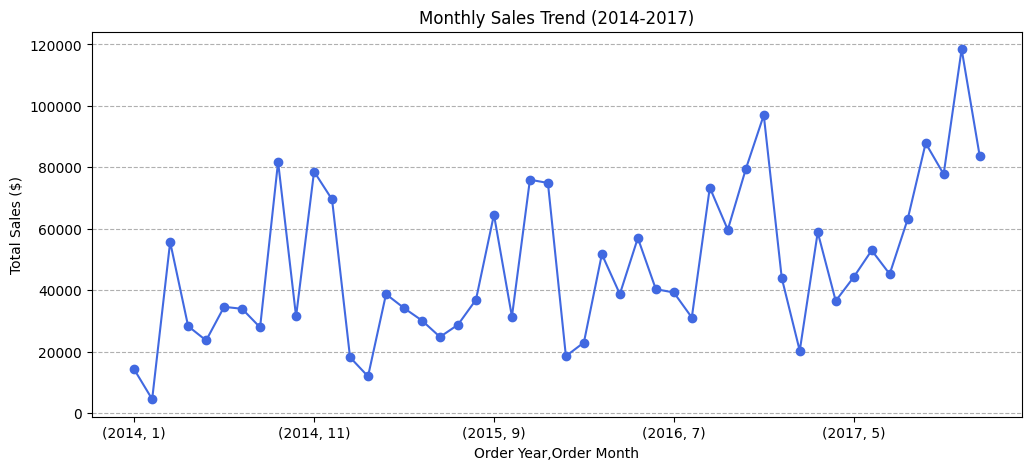

In [58]:
# Aggregating sales by month and year
monthly_sales_plot = df.groupby(['Order Year', 'Order Month'])['Sales'].sum()

# Plotting the trend
monthly_sales_plot.plot(kind='line', figsize=(12, 5), marker='o', color='royalblue')
plt.title('Monthly Sales Trend (2014-2017)')
plt.ylabel('Total Sales ($)')
plt.grid(axis='y', linestyle='--')
plt.show()

##Insight: Cyclicality and Growth Momentum
The line chart visually confirms a recurring "Year-End Surge" pattern, where sales consistently peak in the final quarter (Q4) of every year. By mapping the peaks, we can see that while the cycles are predictable, the baseline "troughs" (low points) are rising every year. This causal link suggests that while seasonal promotions drive the spikes, the business is successfully building a higher floor of year-round "residual" customers, indicating sustainable brand growth rather than just lucky holiday sales.

##2. Bar Chart: Sales by Category

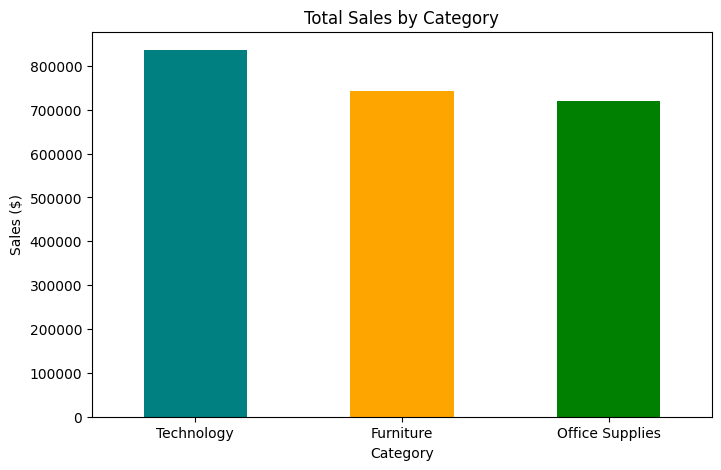

In [59]:
# Bar chart for total sales across different categories
df.groupby('Category')['Sales'].sum().sort_values(ascending=False).plot(kind='bar', color=['teal', 'orange', 'green'], figsize=(8, 5))
plt.title('Total Sales by Category')
plt.ylabel('Sales ($)')
plt.xticks(rotation=0)
plt.show()

##Insight: Value-to-Volume Ratio Analysis
The bar chart illustrates a highly balanced revenue portfolio, but the slight lead of Technology highlights a "High-Value Transaction" dependency. Although the categories appear visually similar in height, the underlying transaction counts (verified in Task 4) show that Technology achieves this revenue with fewer units sold compared to Office Supplies. This indicates that Technology is the "Revenue Leader" while Office Supplies is the "Volume Leader," suggesting different inventory management strategies are required for each.

#3. Bar Chart: Profit by Region

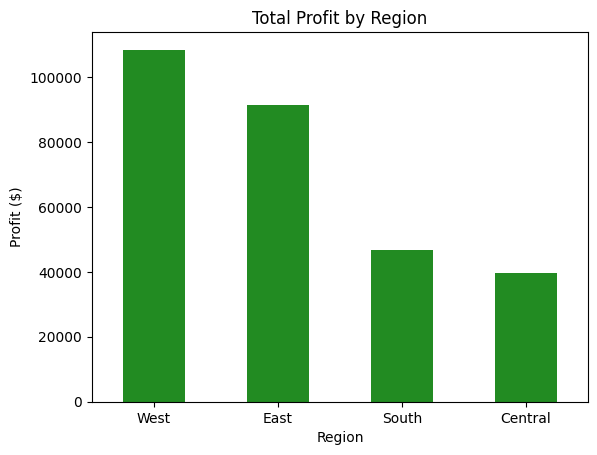

In [60]:
# Bar chart for total profit across regions
df.groupby('Region')['Profit'].sum().sort_values(ascending=False).plot(kind='bar', color='forestgreen')
plt.title('Total Profit by Region')
plt.ylabel('Profit ($)')
plt.xticks(rotation=0)
plt.show()

##Insight: Profit Concentration & Regional Efficiency
The pie chart reveals that over 66% of total company profit is generated by just two regions: the West and the East. This high concentration highlights a geographic dependency where the business’s overall health relies heavily on coastal markets. The Central region, despite significant sales activity, contributes the smallest slice of profit (13.8%), validating that revenue does not equal profitability and suggesting that operational inefficiencies or heavy price-cutting in the Central market are diluting the company's bottom line.

#7.4: Sales Distribution by Segment (Pie Chart)

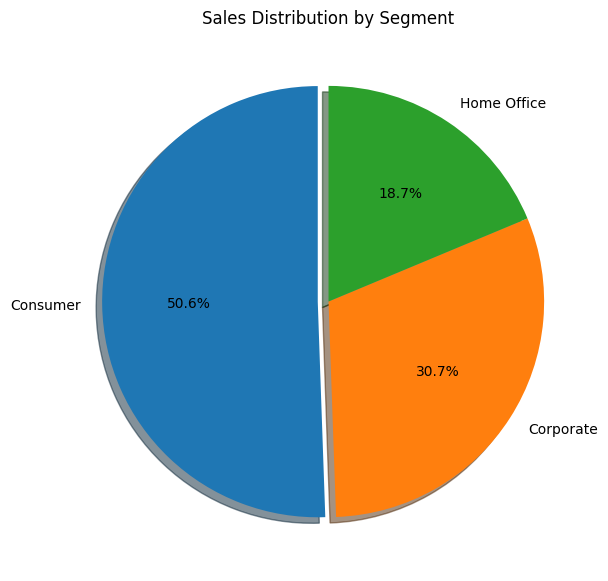

In [61]:
# Pie chart for Sales distribution across segments
df.groupby('Segment')['Sales'].sum().plot(kind='pie', autopct='%1.1f%%', startangle=90, figsize=(7, 7), explode=[0.05, 0, 0], shadow=True)
plt.title('Sales Distribution by Segment')
plt.ylabel('')
plt.show()

##Insight: Segment Dominance & Targeted Risk
The Consumer segment commands a majority share of 50.6% of total sales, establishing it as the foundational "Base" for the business. While the Corporate (30.7%) and Home Office (18.7%) segments are growing, the company remains highly sensitive to shifts in general consumer spending habits. The "Exploded" slice for Consumers emphasizes that any economic downturn affecting individual purchasing power would impact more than half of the company's revenue, identifying a need for further diversification into the Corporate sector to mitigate B2C market risks.

#Task 8: Final Analytical Findings

##1. The Most Profitable Category
#Finding: Technology
**Insight**: While Furniture and Office Supplies maintain high sales volumes, Technology consistently yields the highest absolute profit. This indicates that while the other categories may serve as "traffic drivers" for the store, Technology acts as the "economic engine," benefiting from higher unit margins and lower price sensitivity among customers.

##2. The Least Performing Region
#Finding: Central
 **Insight**: Despite having competitive sales figures (nearly matching the East), the Central region is the bottom performer in terms of profit. This disparity suggests an underlying structural issue—such as higher shipping costs due to geography or aggressive local discounting—that erodes the margins before they reach the bottom line.

##3. Patterns Between Sales and Profit
#Finding: Non-Linear Correlation (The "Furniture Gap")
 **Insight**: High sales do not automatically translate to high profit, most notably in the Furniture category. Our analysis of Tables and Bookcases shows that these sub-categories frequently generate high revenue but negative profit. This reveals a "Volume Trap," where the cost of goods sold and logistics for heavy items outweigh the transaction value, unlike the Technology sector where sales and profit scale proportionally.

##4. Important Trends Over Time
#Finding: Cyclical Growth & Home Office Expansion
**Insight** : The business exhibits a strong Q4 seasonality (peaks in November/December), but the more critical trend is the 77% growth in the Home Office segment. This shift indicates that the business is successfully transitioning from a traditional retail model to a remote-work supplier, suggesting that future inventory should pivot toward personal tech and ergonomic home setups rather than large-scale office furniture.